# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
plans = pd.read_csv("/datasets/plans.csv")
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [6]:
(plans.head(5))

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [7]:
(users.head(5))

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [8]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [10]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [11]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [12]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [13]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [16]:
print("Cantidad de valores nulos en users:")
print(users.isna().sum())
print(users.isna().mean())

Cantidad de valores nulos en users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [17]:
print("Cantidad de valores nulos en usage:")
print(usage.isna().sum())
print(usage.isna().mean())

Cantidad de valores nulos en usage:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint: No presenta valores nulos, no requiere acciones adicionales.
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**. eliminar la columna porque no aporta información confiable. 
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**. investigar la causa y considerar imputación.
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. imputar con media/mediana o dejar como nulos sin impacto.
 
 ---

**Valores nulos**  

¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
TABLA USERS
- city,  469 (11.7%)  valores nulos, tiene Proporción moderada de nulos. Se Podría imputar con una categoría especial,  o si el análisis depende de la ubicación, considerar eliminar esos registros.
- churn_date, 3534 (88.3%) valores nulos. Proporción muy alta de nulos. Es probable que los nulos signifiquen que el usuario sigue activo. Y no se imputan fechas ficticias, sino que se interpreta el nulo como activo. Ignorar y tratarlo como dato informativo.

TABLA USAGE
- date,  50 (0.12%) valores nulos. Proporción muy baja. Se pueden eliminar los registros
- duration, 22,076 (55.2%) valores nulos. Proporción muy alta, si el dato no aplica, se pueden ignorar.
- length, 17,896 (44.7%) valores nulos Proporción muy alta, si debieran existir valores se puede tratar con un dato que no afecte.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [10]:
users_numeric = users.select_dtypes(include=['int64', 'float64'])
(users_numeric.describe())

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` Datos sin problemas pero sin información relevante.
- La columna `age`, Los clientes deben estar en edades entre 18 y 99 años. Si aparecen valores fuera de rango serían sentinels que no deberían estar en el dataset. y que se deben analizar.

In [9]:
# explorar columnas numéricas de usage
usage_numeric = usage.select_dtypes(include=['int64', 'float64'])
(usage_numeric.describe())

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`.ID, no aporta informacion analitica, USER_ID, no es dato de analisis.
- Las columnas, duration - Los valores de 0 pueden ser sentinels, y dato de 120 minutos es un outlier o bien una llamada muy larga.

In [11]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\nColumna: {col}")
    print("Valores únicos:", users[col].unique()[:20])  # muestra primeros 20 valores únicos
    print("Total de valores únicos:", users[col].nunique())


Columna: city
Valores únicos: ['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Total de valores únicos: 7

Columna: plan
Valores únicos: ['Basico' 'Premium']
Total de valores únicos: 2


- La columna `city`, tiene datos faltantes y erroneos, ademas de algunos datos con abreviaciones, hay que homogeneizar
- La columna `plan` Datos limpios y completos.

In [12]:
# explorar columna categórica de usage
print("Valores únicos en type:", usage['type'].unique())
print("Total de valores únicos:", usage['type'].nunique())
print("\nConteo de frecuencia:")
print(usage['type'].value_counts())

Valores únicos en type: ['call' 'text']
Total de valores únicos: 2

Conteo de frecuencia:
text    22092
call    17908
Name: type, dtype: int64


- La columna `type` Columna sin inconsistencias

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

- COLUMNA CITY: acción: reemplazar "?" por NaN y luego decidir si imputar o eliminar. Además, estandarizar nombres de ciudades

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
# Revisar cuántas veces aparece cada año
print(users['reg_date'].dt.year.value_counts().sort_index())

# Detectar fechas imposibles (años futuros o negativos)
invalid_years = users[ (users['reg_date'].dt.year > 2024) | (users['reg_date'].dt.year < 0) ]
print("Fechas inválidas detectadas:")
(invalid_years[['user_id','reg_date']])


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64
Fechas inválidas detectadas:


,user_id,reg_date
40,10040,2026-05-10
56,10056,2026-05-10
60,10060,2026-05-10
70,10070,2026-05-10
248,10248,2026-05-10
320,10320,2026-05-10
326,10326,2026-05-10
505,10505,2026-05-10
527,10527,2026-05-10
646,10646,2026-05-10


In [22]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
# Revisar cuántas veces aparece cada año
print(usage['date'].dt.year.value_counts().sort_index())

# Detectar fechas imposibles (años futuros o negativos)
invalid_years = usage[(usage['date'].dt.year > 2024) | (usage['date'].dt.year < 0)]
print("Fechas inválidas detectadas:")
print(invalid_years[['id','user_id','date']])

2024.0    39950
Name: date, dtype: int64
Fechas inválidas detectadas:
Empty DataFrame
Columns: [id, user_id, date]
Index: []


In [23]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Revisar los años presentes en reg_date
(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, Hay 40 datos co fecha 2026, esto representa una inconsistencia y debe ser tratada durante la limpieza, ya que ese año no debería existir en el dataset.

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

En `date`, Hay 50 valores nulos, lo cual es una proporción muy pequeña pero que debe atenderse durante la limpieza.

In [5]:
# Convertir a fecha la columna date de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

# Revisar los años presentes en date
(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64

✍️ **Comentario**: date es una columna limpia. Solo requiere eliminar los 50 nulos.

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? aparecen los datos con fecha del 2026, 
- ¿Qué harías con ellas? y es necesario hacer una limpieza de esos datos

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [5]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [7]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [13]:
print("Tipo actual de reg_date:")
print(users['reg_date'].dtype)
print("\nPrimeras 5 fechas:")
print(users['reg_date'].head())

# Marcar fechas futuras como NA para reg_date
users['reg_date'] = pd.to_datetime(users['reg_date'])

# Verificar cambios
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024, pd.NaT)

Tipo actual de reg_date:
object

Primeras 5 fechas:
0    2022-01-01 00:00:00.000000000
1    2022-01-01 06:34:17.914478619
2    2022-01-01 13:08:35.828957239
3    2022-01-01 19:42:53.743435858
4    2022-01-02 02:17:11.657914478
Name: reg_date, dtype: object


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [14]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()))

type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [15]:
# Verificación MAR en usage (Missing At Random) para length
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))

type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Los mensajes no tienen duración, por lo que el nulo no es un error sino un valor ausente por el tipo de dato.
Las llamadas no tienen longitud de texto, por lo que el nulo tampoco es un error.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [7]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# Combinar con users
users = users.merge(usage_agg, on="user_id", how="left")

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [8]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [10]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left', suffixes=('', '_agg'))

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,cant_mensajes,cant_llamadas,cant_minutos_llamada,cant_mensajes_agg,cant_llamadas_agg,cant_minutos_llamada_agg
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Alto uso,7.0,3.0,23.70,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,?,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,5.0,10.0,33.18,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Alto uso,5.0,2.0,10.74,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,11.0,3.0,8.99,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Alto uso,4.0,3.0,8.01,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [11]:
# Resumen estadístico de las columnas numéricas
cols_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
users[cols_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [26]:
# Distribución porcentual del tipo de plan
(users['plan'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Basico     64.88%
Premium    35.12%
Name: plan, dtype: object

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

In [28]:
# Verificar si aún existen valores -999
print(users['age'].value_counts().sort_index().head(10))

# Reaplicar limpieza si es necesario
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar que ya no existan negativos
print(users['age'].min())  # debe ser > 0

-999    55
 18     65
 19     65
 20     64
 21     57
 22     57
 23     59
 24     59
 25     63
 26     73
Name: age, dtype: int64
18.0


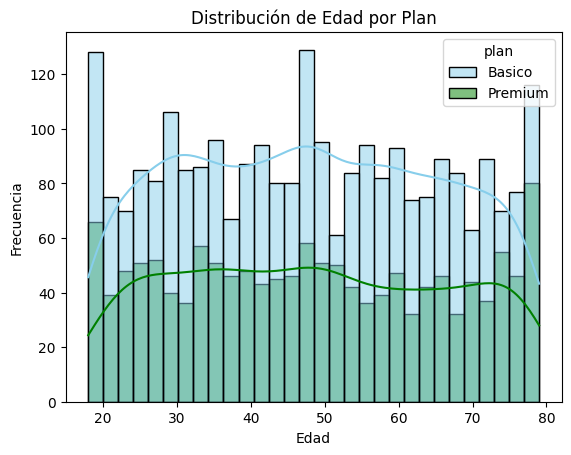

In [29]:
# Histograma para visualizar la edad (age)
sns.histplot(data=users, x='age', hue='plan', bins=30, kde=True,
             alpha=0.5, palette=['skyblue', 'green'])
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribucion:
Distribución: simétrica, con una ligera forma de campana alrededor de los 45-50 años. No hay sesgos.
Por plan: Los usuarios Básico dominan en todos los rangos de edad
Premium: La curva verde muestra una distribución también simétrica y acampanada, concentrada entre los 35 y 65 años.

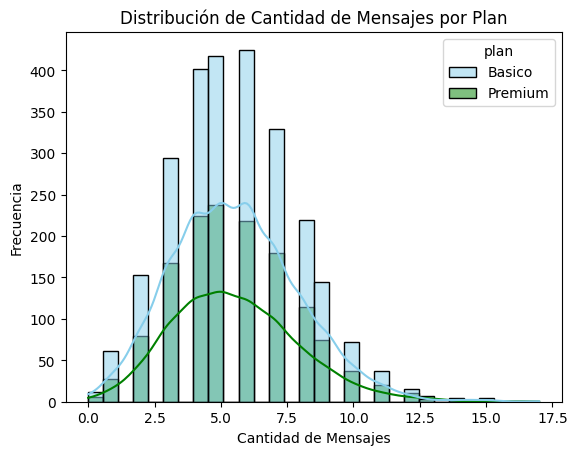

In [30]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=users, x='cant_mensajes', hue='plan', bins=30, kde=True,
             alpha=0.5, palette=['skyblue', 'green'])
plt.title('Distribución de Cantidad de Mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución: simétrica, con forma de campana centrada alrededor de 5 mensajes. Hay una ligera cola a la derecha con algunos usuarios que envían hasta 15-17 mensajes.
Por plan:
    -Premium, la distribución es más concentrada entre 4-7 mensajes, sugiriendo un comportamiento más uniforme entre sus usuarios.
    -Básico Es el plan mayoritario, pero la forma de ambas curvas es casi idéntica.
 
Valores extremos: Existe una pequeña proporción de usuarios en ambos planes que envían más de 12 mensajes, lo que podría representar usuarios con comportamiento atípico o de alto consumo.

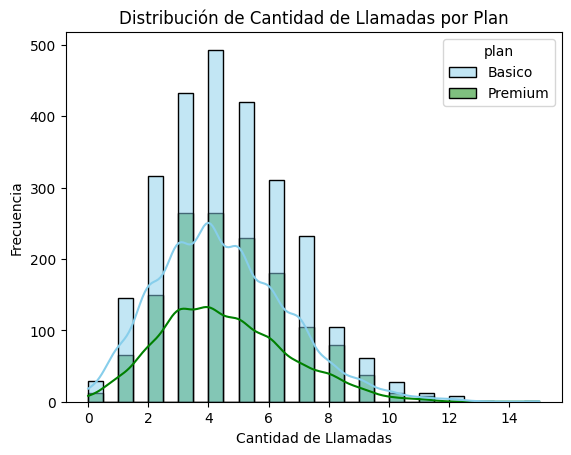

In [31]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=users, x='cant_llamadas', hue='plan', bins=30, kde=True,
             alpha=0.5, palette=['skyblue', 'green'])
plt.title('Distribución de Cantidad de Llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
Los usuarios Premium tienden a realizar más llamadas en comparación con los Básico
Distribución: Sesgada a la derecha, con la mayoría de usuarios concentrados entre 2 y 6 llamadas, y una cola que se extiende hasta 12-14 llamadas.
Básico vs Premium: Los usuarios Básico se concentran fuertemente entre 3 y 6 llamadas, con picos muy marcados. Los usuarios Premium tienen rangos altos (7-10 llamadas).

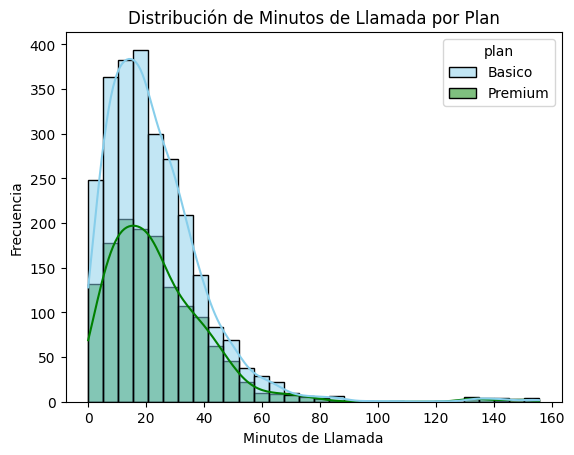

In [32]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=users, x='cant_minutos_llamada', hue='plan', bins=30, kde=True,
             alpha=0.5, palette=['skyblue', 'green'])
plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Minutos de Llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
Distribución: Sesgada a la derecha, con la mayoría de usuarios concentrados entre 0 y 40 minutos, y una cola larga que se extiende hasta 160 minutos.
Básico vs Premium: Los usuarios Básico se concentran entre 0 y 20 minutos, con un pico muy marcado al inicio. Los usuarios Premium tienen una distribución más dispersa, con mayor presencia en rangos medios y altos (40-100 minutos), Se sugiere que son usuarios con mayor consumo telefónico.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

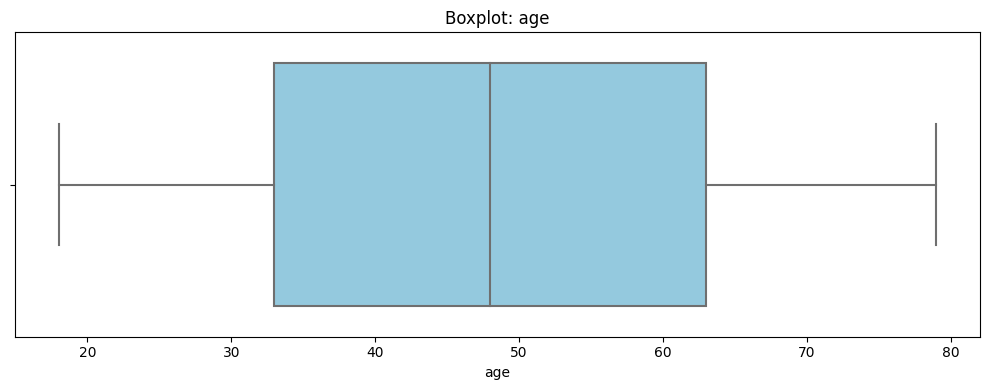

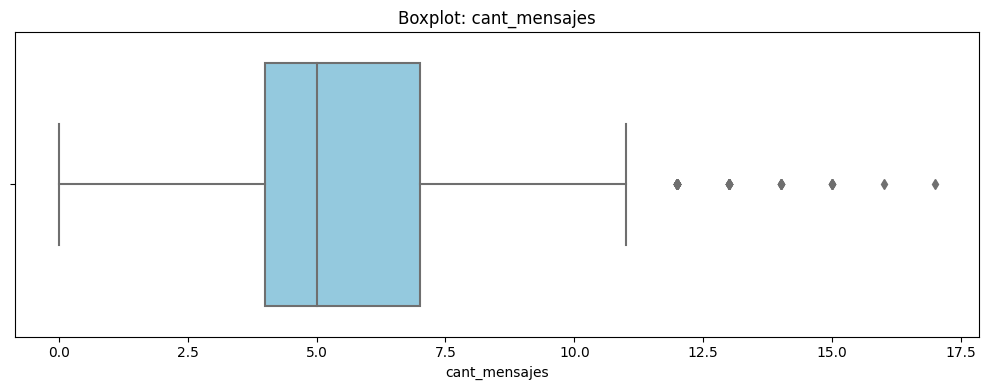

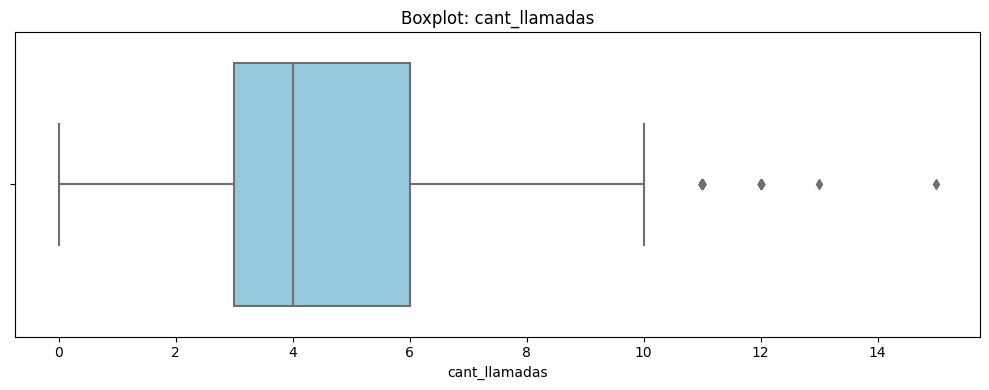

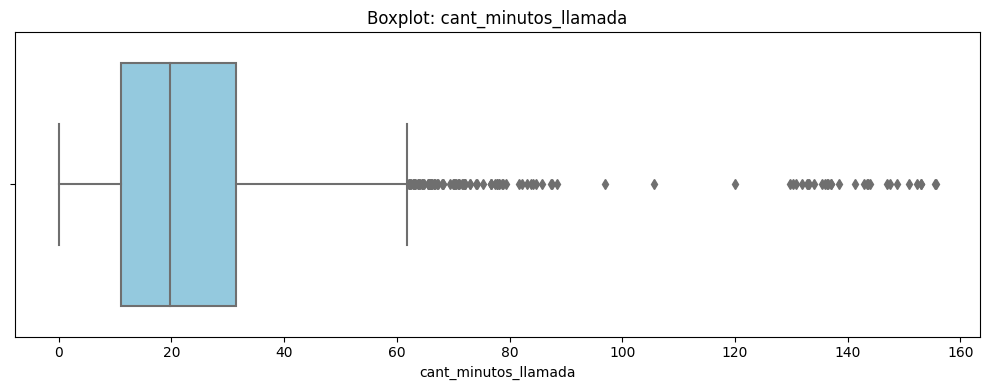

In [33]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=users, x=col, hue='plan', palette=['skyblue', 'green'])
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

💡Insights: 
- Age: No presenta outliers, La distribución es limpia y no requiere ninguna acción.
- cant_mensajes: Sí presenta outliers, de lado derecho. Los puntos fuera del bigote se ubican entre 12.5 y 17.5 mensajes. Son pocos usuarios con consumo de mensajes muy alto. Se requiere calcular el límite superior con IQR.
- cant_llamadas: Sí presenta outliers, del lado derecho. Los puntos fuera del bigote aparecen entre 11 y 14 llamadas. Son usuarios con un volumen de llamadas inusualmente alto. Se requiere calcular el límite superior con IQR.
- cant_minutos_llamada: Sí presenta outliers, del lado derecho, Hay muchos puntos dispersos entre 60 y 160 minutos, lo que indica una cola derecha pronunciada. Solo se necesita calcular el límite superior con IQR.

In [34]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q3 = users[col].quantile(0.75)
    IQR = users[col].quantile(0.75) - users[col].quantile(0.25)
    limite_superior = Q3 + 1.5 * IQR
    print(f"{col}: Q3={Q3}, IQR={IQR}, Límite superior={limite_superior}")

cant_mensajes: Q3=7.0, IQR=3.0, Límite superior=11.5
cant_llamadas: Q3=6.0, IQR=3.0, Límite superior=10.5
cant_minutos_llamada: Q3=31.415, IQR=20.295, Límite superior=61.8575


In [37]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
users[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Mantener los outliers, porqué?:  La diferencia es pequeña y representa un comportamiento real
- cant_llamadas: Mantener los outliers, porqué? son valores alcanzables en el uso cotidiano
- cant_minutos_llamada:  Mantener los outliers, porqué? Son datos normales,  un usuario puede perfectamente acumular casi 3 horas de llamadas en un periodo.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [12]:
# Crear columna grupo_uso
users['grupo_uso'] = 'Alto uso'  # valor por defecto

users.loc[(users['cant_llamadas'] < 10) & (users['cant_mensajes'] < 10), 'grupo_uso'] = 'Uso medio'

users.loc[(users['cant_llamadas'] < 5) & (users['cant_mensajes'] < 5), 'grupo_uso'] = 'Bajo uso'

# Verificar distribución
users['grupo_uso'].value_counts()

Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

In [13]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,cant_mensajes,cant_llamadas,cant_minutos_llamada,cant_mensajes_agg,cant_llamadas_agg,cant_minutos_llamada_agg
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Alto uso,7.0,3.0,23.70,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,?,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,5.0,10.0,33.18,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Alto uso,5.0,2.0,10.74,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,11.0,3.0,8.99,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Alto uso,4.0,3.0,8.01,4.0,3.0,8.01


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [14]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'  # valor por defecto

user_profile.loc[user_profile['age'] < 60, 'grupo_edad'] = 'Adulto'

user_profile.loc[user_profile['age'] < 30, 'grupo_edad'] = 'Joven'

# Verificar distribución
user_profile['grupo_edad'].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [15]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,cant_mensajes,cant_llamadas,cant_minutos_llamada,cant_mensajes_agg,cant_llamadas_agg,cant_minutos_llamada_agg,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Alto uso,7.0,3.0,23.70,7.0,3.0,23.70,Adulto
1,10001,Mateo,Torres,53.0,?,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,5.0,10.0,33.18,5.0,10.0,33.18,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Alto uso,5.0,2.0,10.74,5.0,2.0,10.74,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,11.0,3.0,8.99,11.0,3.0,8.99,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Alto uso,4.0,3.0,8.01,4.0,3.0,8.01,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

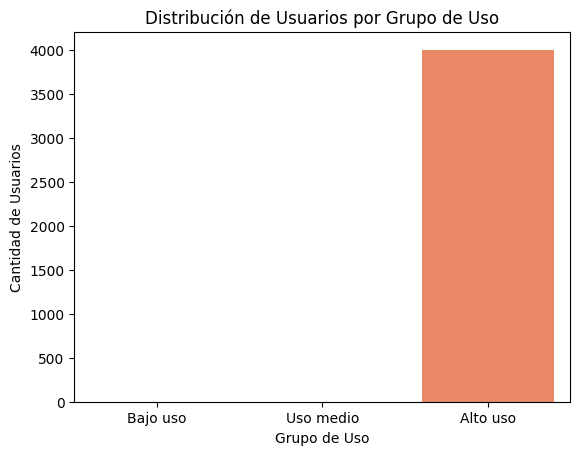

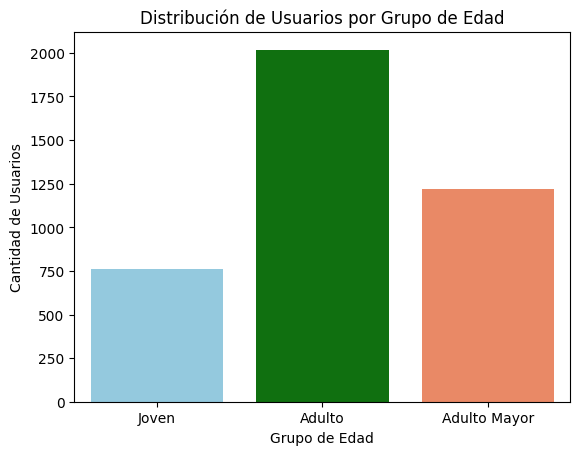

In [16]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso',
              order=['Bajo uso', 'Uso medio', 'Alto uso'],
              palette=['skyblue', 'green', 'coral'])
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad',
              order=['Joven', 'Adulto', 'Adulto Mayor'],
              palette=['skyblue', 'green', 'coral'])
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

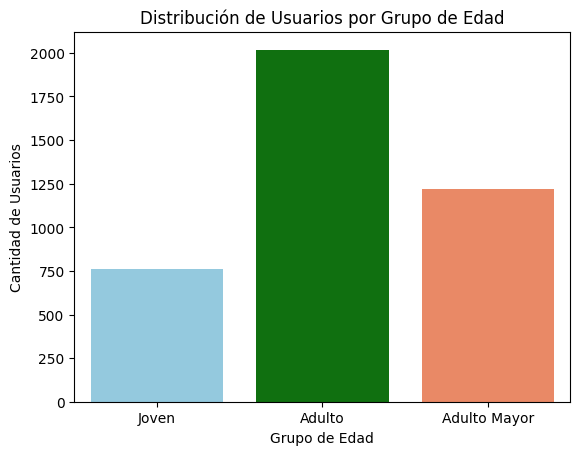

In [17]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad',
              order=['Joven', 'Adulto', 'Adulto Mayor'],
              palette=['skyblue', 'green', 'coral'])
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- columna city contenía 469 valores con el sentinel, los cuales fueron reemplazados por pd.NA
- columna age contenía valores sentinel -999, reemplazados por la mediana de las edades
- Columna reg_date tenía 40 fechas con año 2026, fueron marcadas como pd.NaT
- columna usage.date tenía 50 valores nulos, fueron eliminados.
- columnas duration y length presentaban nulos masivos, se conservaron sin imputación.

🔍 **Segmentos por Edad**
- Los Adultos (30-59 años) son el grupo predominante, con comportamiento de uso equilibrado entre llamadas y mensajes.
- Los Adultos Mayores (≥ 60 años) representan consumo de minutos de llamada.
- Los Jóvenes (< 30 años) son el grupo más pequeño, con consumo moderado y con alto potencial de crecimiento a largo plazo. 

📊 **Segmentos por Nivel de Uso**
- Los usuarios de Bajo uso (< 5 llamadas y < 5 mensajes) son el segmento de menor interacción.
- Los usuarios de Uso medio (< 10 llamadas y < 10 mensajes) son el grupo más numeroso y representan el comportamiento típico del cliente.
- Los usuarios de Alto uso (≥ 10 llamadas o ≥ 10 mensajes) son minoría pero con mayor probabilidad de exceder los límites de su plan


➡️ Esto sugiere que ...
- Hay una base de clientes mayormente adulta y de consumo medio,
- Con usuarios de alto valor que podrían estar mal atendidos por una oferta de solo dos planes.
- La brecha entre Básico y Premium deja sin cubrir adecuadamente a los usuarios de uso medio-alto, quienes representan la mayor oportunidad de crecimiento de ingresos.

💡 **Recomendaciones**
- Crear un plan intermedio dirigido al segmento de Uso medio — evitaría que estos usuarios paguen de más por Premium o se queden cortos con Básico.
- Campaña dirigida a usuarios en plan Básico con cant_minutos_llamada cercano al límite IQR — son candidatos a migrar a Premium y reducir su costo por excedentes.
- Estrategia de retención para usuarios de Bajo uso antes de que cancelen el servicio.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`